##### ARTI 560 - Computer Vision

## Visual Representations with DINOv2 - Exercise

### Exercise 1: Unsupervised Clustering

In this exercise, you will use the `KMeans` algorithm from sklearn to group 20 images from the Oxford Pet dataset into 2 clusters (Cats vs. Dogs) based purely on their CLS tokens.

Instructions:

1.  Extract the 384-dimensional [CLS] tokens from 20 images of the Oxford-IIIT Pet dataset. Ensure your selection includes a mix of both cats and dogs.

2. Apply K-Means Clustering ($n=2$) to group the vectors based on mathematical similarity rather than provided labels.

3. Compare the predicted clusters against ground-truth labels.

Loading weights:   0%|          | 0/223 [00:00<?, ?it/s]

Model loaded
LOADING IMAGES
Found 2400 cat images and 4990 dog images

Extracting CLS tokens
   1/20: Abyssinian_20.jpg                   - CAT
   2/20: Maine_Coon_219.jpg                  - CAT
   3/20: Russian_Blue_136.jpg                - CAT
   4/20: Abyssinian_2.jpg                    - CAT
   5/20: Russian_Blue_18.jpg                 - CAT
   6/20: Bombay_64.jpg                       - CAT
   7/20: Maine_Coon_270.jpg                  - CAT
   8/20: Egyptian_Mau_121.jpg                - CAT
   9/20: Bombay_129.jpg                      - CAT
  10/20: Bombay_161.jpg                      - CAT
  11/20: staffordshire_bull_terrier_159.jpg  - DOG
  12/20: boxer_92.jpg                        - DOG
  13/20: keeshond_21.jpg                     - DOG
  14/20: basset_hound_16.jpg                 - DOG
  15/20: pug_191.jpg                         - DOG
  16/20: boxer_164.jpg                       - DOG
  17/20: shiba_inu_160.jpg                   - DOG
  18/20: saint_bernard_33.jpg           

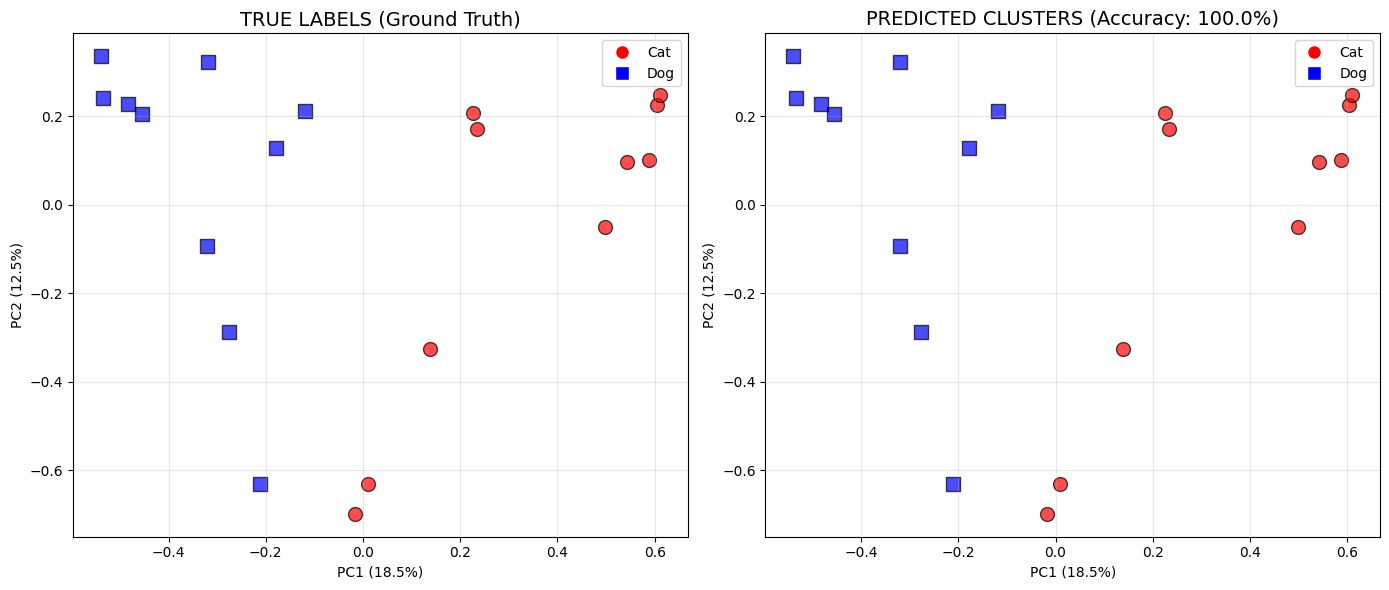

MISCLASSIFIED IMAGES ANALYSIS
All images correctly classified


In [9]:
import torch
import torch.nn.functional as F
import numpy as np
import matplotlib.pyplot as plt
from PIL import Image
from sklearn.cluster import KMeans
from sklearn.metrics import accuracy_score, confusion_matrix
from transformers import AutoImageProcessor, AutoModel
import os
import random

MODEL_ID = "facebook/dinov2-small"
device = "cuda" if torch.cuda.is_available() else "cpu"

processor = AutoImageProcessor.from_pretrained(MODEL_ID)
model = AutoModel.from_pretrained(MODEL_ID).to(device)
model.eval()
print("Model loaded")

def load_cats_and_dogs_from_oxford(data_dir="data/images", num_cats=10, num_dogs=10):
    image_paths = []
    true_labels = []  # 0 = cat, 1 = dog

    all_files = [f for f in os.listdir(data_dir) if f.endswith('.jpg')]

    cat_files = [f for f in all_files if f[0].isupper()]
    dog_files = [f for f in all_files if f[0].islower()]

    print(f"Found {len(cat_files)} cat images and {len(dog_files)} dog images")

    random.seed(42)
    selected_cats = random.sample(cat_files, min(num_cats, len(cat_files)))
    selected_dogs = random.sample(dog_files, min(num_dogs, len(dog_files)))

    for cat_file in selected_cats:
        image_paths.append(os.path.join(data_dir, cat_file))
        true_labels.append(0)

    for dog_file in selected_dogs:
        image_paths.append(os.path.join(data_dir, dog_file))
        true_labels.append(1)

    return image_paths, true_labels

def get_global_embedding(image_path):
    img = Image.open(image_path).convert("RGB")
    inputs = processor(images=img, return_tensors="pt").to(device)
    with torch.no_grad():
        outputs = model(**inputs)
        cls_token = outputs.last_hidden_state[:, 0]
        return F.normalize(cls_token, p=2, dim=1).cpu().numpy().flatten()

print("LOADING IMAGES")

image_paths, true_labels = load_cats_and_dogs_from_oxford(num_cats=10, num_dogs=10)

print("\nExtracting CLS tokens")
embeddings = []
valid_paths = []
valid_labels = []

for i, (path, label) in enumerate(zip(image_paths, true_labels)):
    try:
        embedding = get_global_embedding(path)
        embeddings.append(embedding)
        valid_paths.append(path)
        valid_labels.append(label)

        animal = "CAT" if label == 0 else "DOG"
        print(f"  {len(embeddings):2d}/20: {os.path.basename(path)[:35]:<35} - {animal}")
    except Exception as e:
        print(f"  Failed: {os.path.basename(path)} - {e}")

embeddings = np.array(embeddings)
valid_labels = np.array(valid_labels)

print(f"\nEmbeddings shape: {embeddings.shape}")

print("\nApplying K-Means clustering...")
kmeans = KMeans(n_clusters=2, random_state=42, n_init=10)
cluster_labels = kmeans.fit_predict(embeddings)

print(f"Cluster distribution: Cluster 0 has {sum(cluster_labels == 0)} images, Cluster 1 has {sum(cluster_labels == 1)} images")

cluster_0_cats = sum((cluster_labels == 0) & (valid_labels == 0))
cluster_0_dogs = sum((cluster_labels == 0) & (valid_labels == 1))
cluster_1_cats = sum((cluster_labels == 1) & (valid_labels == 0))
cluster_1_dogs = sum((cluster_labels == 1) & (valid_labels == 1))

print(f"\nCluster analysis:")
print(f"  Cluster 0: {cluster_0_cats} cats, {cluster_0_dogs} dogs")
print(f"  Cluster 1: {cluster_1_cats} cats, {cluster_1_dogs} dogs")

if cluster_0_cats > cluster_0_dogs:
    mapped_labels = np.where(cluster_labels == 0, 0, 1)
else:
    mapped_labels = np.where(cluster_labels == 0, 1, 0)

accuracy = accuracy_score(valid_labels, mapped_labels)
print(f"CLUSTERING RESULTS")
print(f"Accuracy: {accuracy * 100:.2f}%")
print(f"Correctly clustered: {sum(valid_labels == mapped_labels)}/{len(valid_labels)}")

print("\nDetailed Results:")
print(f"{'Image':<40} {'True':<8} {'Predicted':<10} {'Correct':<8}")
print("-" * 70)

for i, path in enumerate(valid_paths):
    true_label = "DOG" if valid_labels[i] else "CAT"
    pred_label = "DOG" if mapped_labels[i] else "CAT"
    correct = "Yes" if valid_labels[i] == mapped_labels[i] else "No"
    print(f"{os.path.basename(path):<40} {true_label:<8} {pred_label:<10} {correct:<8}")

cm = confusion_matrix(valid_labels, mapped_labels)
print("\nConfusion Matrix:")
print("              Predicted")
print("              Cat    Dog")
print(f"Actual Cat    {cm[0,0]:<6} {cm[0,1]}")
print(f"Actual Dog    {cm[1,0]:<6} {cm[1,1]}")

from sklearn.decomposition import PCA

pca = PCA(n_components=2)
embeddings_2d = pca.fit_transform(embeddings)

plt.figure(figsize=(14, 6))

# True labels
plt.subplot(1, 2, 1)
for i, (x, y) in enumerate(embeddings_2d):
    color = 'red' if valid_labels[i] == 0 else 'blue'
    marker = 'o' if valid_labels[i] == 0 else 's'
    plt.scatter(x, y, c=color, marker=marker, s=100, edgecolors='black', alpha=0.7)
plt.title('TRUE LABELS (Ground Truth)', fontsize=14)
plt.xlabel(f'PC1 ({pca.explained_variance_ratio_[0]*100:.1f}%)')
plt.ylabel(f'PC2 ({pca.explained_variance_ratio_[1]*100:.1f}%)')
legend_elements = [
    plt.Line2D([0], [0], marker='o', color='w', markerfacecolor='red', markersize=10, label='Cat'),
    plt.Line2D([0], [0], marker='s', color='w', markerfacecolor='blue', markersize=10, label='Dog')
]
plt.legend(handles=legend_elements, loc='best')
plt.grid(True, alpha=0.3)

# Predicted clusters
plt.subplot(1, 2, 2)
for i, (x, y) in enumerate(embeddings_2d):
    color = 'red' if mapped_labels[i] == 0 else 'blue'
    marker = 'o' if mapped_labels[i] == 0 else 's'
    plt.scatter(x, y, c=color, marker=marker, s=100, edgecolors='black', alpha=0.7)
plt.title(f'PREDICTED CLUSTERS (Accuracy: {accuracy*100:.1f}%)', fontsize=14)
plt.xlabel(f'PC1 ({pca.explained_variance_ratio_[0]*100:.1f}%)')
plt.ylabel(f'PC2 ({pca.explained_variance_ratio_[1]*100:.1f}%)')
plt.legend(handles=legend_elements, loc='best')
plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

print("MISCLASSIFIED IMAGES ANALYSIS")

misclassified_indices = np.where(valid_labels != mapped_labels)[0]
if len(misclassified_indices) > 0:
    print(f"\n{len(misclassified_indices)} images were misclassified:")
    for idx in misclassified_indices:
        true_animal = "CAT" if valid_labels[idx] == 0 else "DOG"
        pred_animal = "CAT" if mapped_labels[idx] == 0 else "DOG"
        print(f"  {os.path.basename(valid_paths[idx]):<40} TRUE: {true_animal} -> PREDICTED: {pred_animal}")
else:
    print("All images correctly classified")

### Exercise 2: Image Classification with DINOv2

In this exercise you'll use a DINOv2 model with a pre-trained linear head to classify an image. You will observe how the model maps visual features to specific ImageNet-1k categories.

Instructions:
1. For this exercise, you must use the following Model ID. This specific checkpoint includes the necessary classification head trained on ImageNet-1k:

    Model ID: `facebook/dinov2-small-imagenet1k-1-layer`

2. Find an image online to make the inference. To ensure the model has a fair chance of success, the image should belong to one of the ImageNet-1k classes (e.g., a Golden Retriever, a grand piano, a school bus, or a coffee mug).

Loading weights:   0%|          | 0/225 [00:00<?, ?it/s]

Model loaded on cuda
Loaded 1000 ImageNet classes

TEST 1: Cat from Oxford Pets dataset


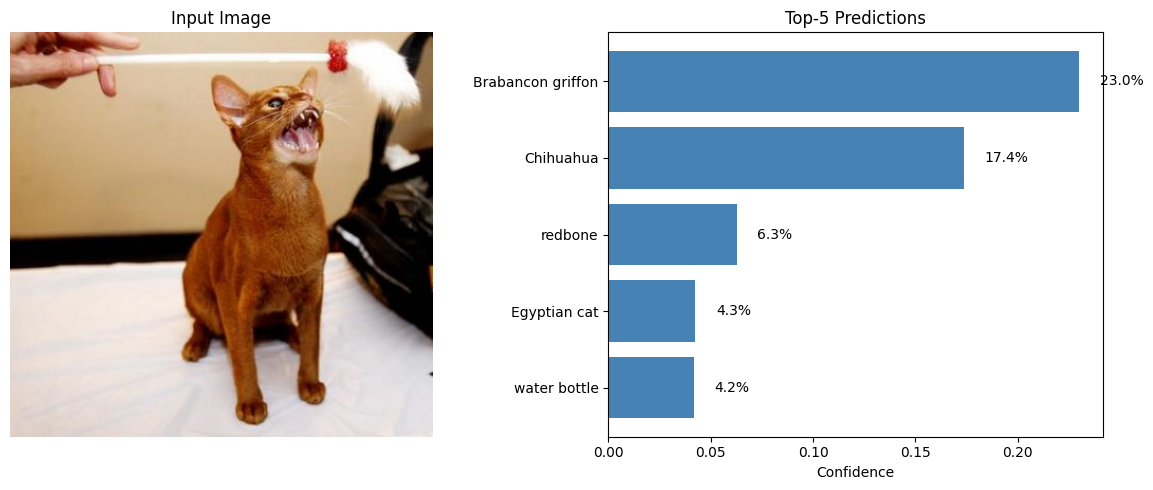


CLASSIFICATION RESULTS
1. Brabancon griffon - 22.99%
2. Chihuahua - 17.39%
3. redbone - 6.27%
4. Egyptian cat - 4.26%
5. water bottle - 4.20%

TEST 2: Dog from Oxford Pets dataset


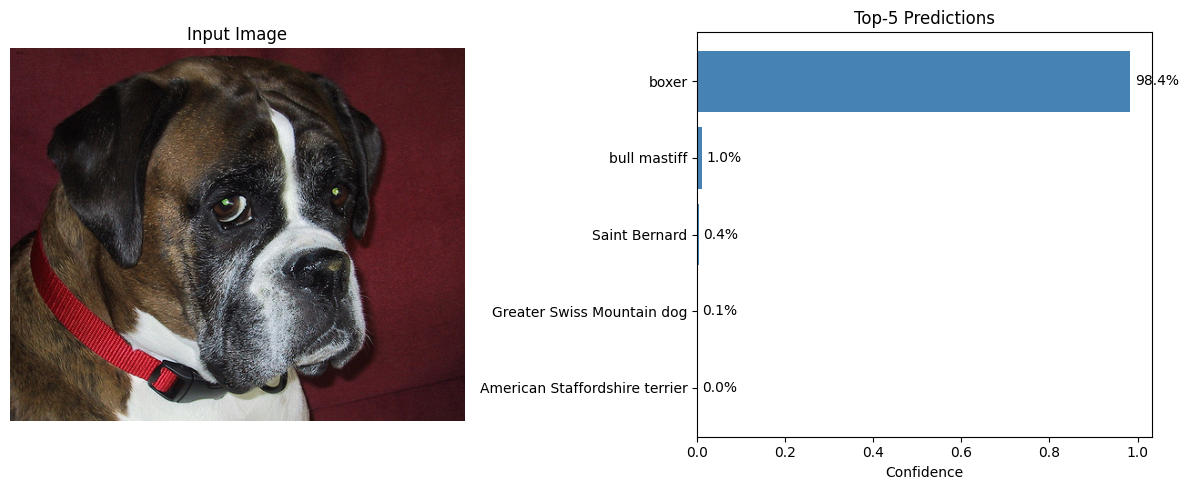


CLASSIFICATION RESULTS
1. boxer - 98.37%
2. bull mastiff - 0.98%
3. Saint Bernard - 0.44%
4. Greater Swiss Mountain dog - 0.07%
5. American Staffordshire terrier - 0.03%

TEST 3: Golden Retriever from web
Could not download image: cannot identify image file <_io.BytesIO object at 0x7867940a20c0>

TEST 4: Sports car from web
Could not download image: cannot identify image file <_io.BytesIO object at 0x7867ababf380>

Testing multiple images

Image: Birman_115.jpg


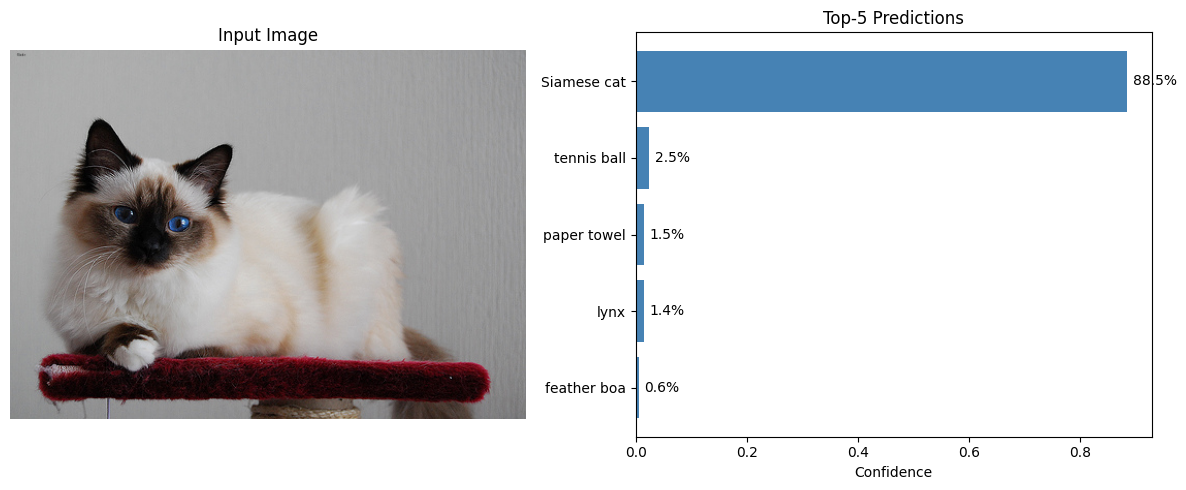


CLASSIFICATION RESULTS
1. Siamese cat - 88.49%
2. tennis ball - 2.46%
3. paper towel - 1.48%
4. lynx - 1.44%
5. feather boa - 0.58%

Image: Ragdoll_47.jpg


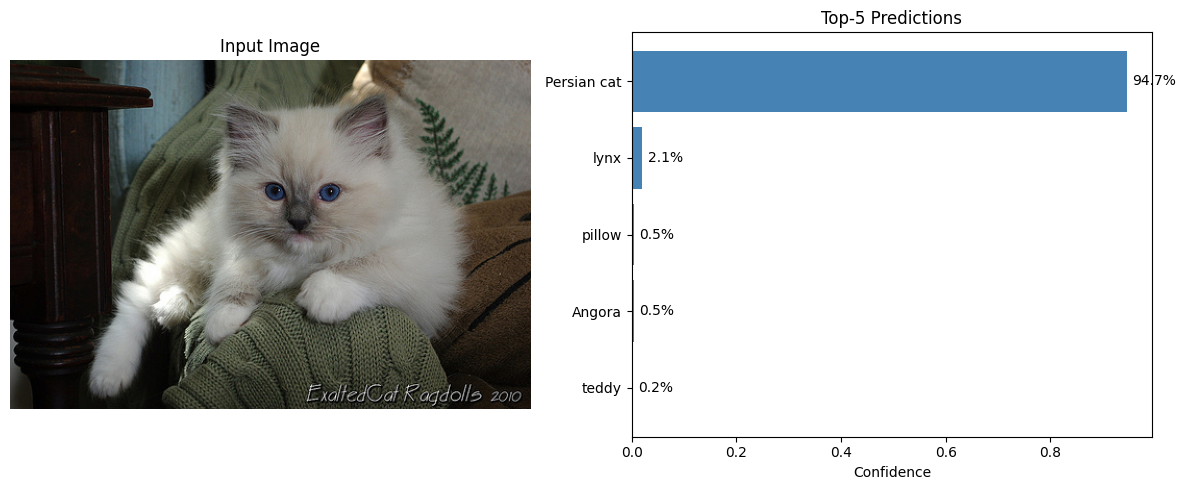


CLASSIFICATION RESULTS
1. Persian cat - 94.66%
2. lynx - 2.06%
3. pillow - 0.50%
4. Angora - 0.48%
5. teddy - 0.23%

Image: Birman_135.jpg


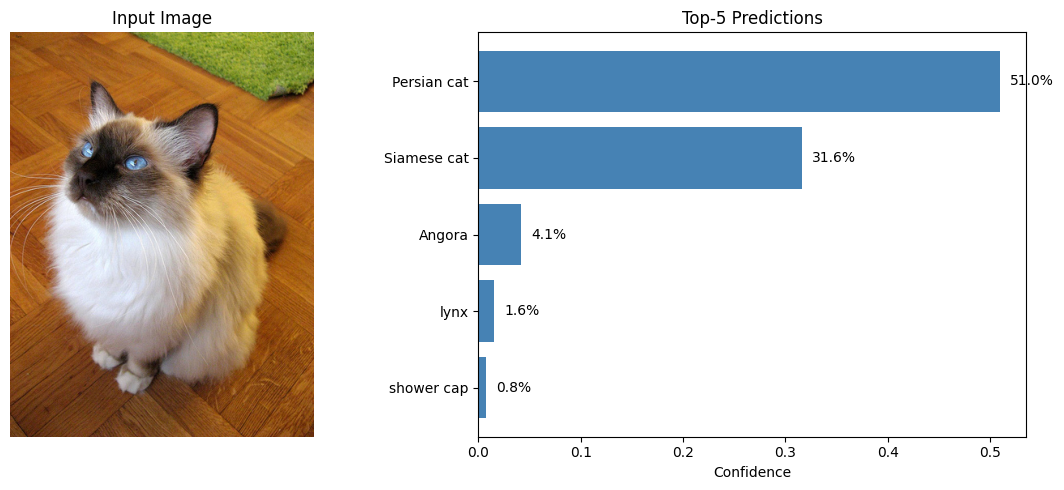


CLASSIFICATION RESULTS
1. Persian cat - 50.98%
2. Siamese cat - 31.60%
3. Angora - 4.14%
4. lynx - 1.56%
5. shower cap - 0.75%

Image: saint_bernard_119.jpg


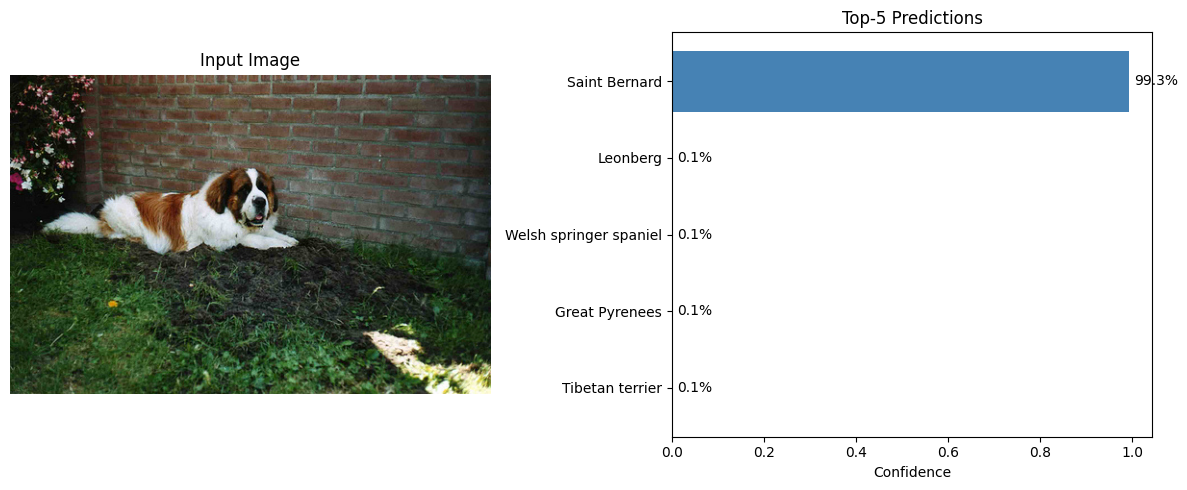


CLASSIFICATION RESULTS
1. Saint Bernard - 99.35%
2. Leonberg - 0.14%
3. Welsh springer spaniel - 0.12%
4. Great Pyrenees - 0.11%
5. Tibetan terrier - 0.07%

Image: saint_bernard_120.jpg


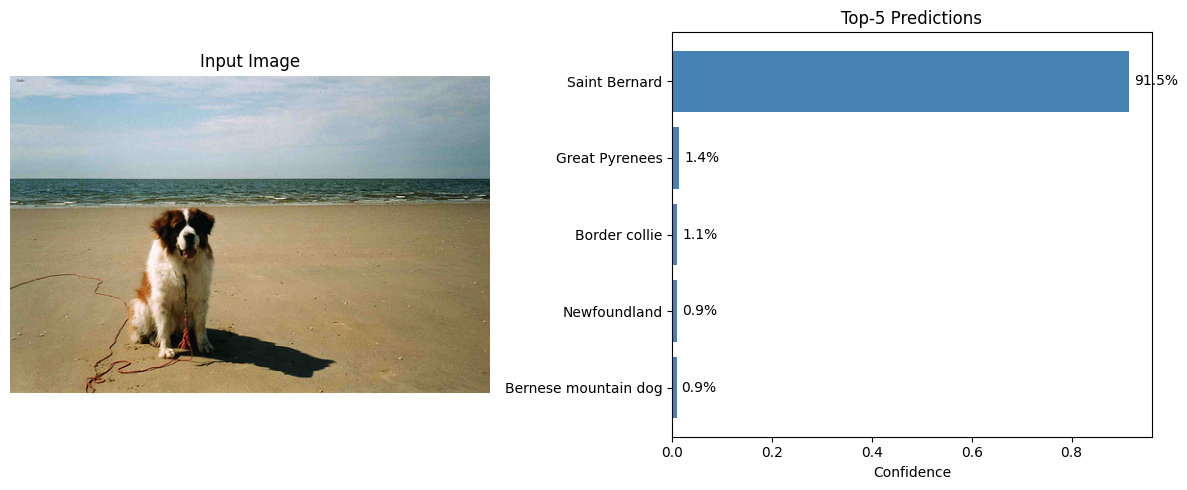


CLASSIFICATION RESULTS
1. Saint Bernard - 91.48%
2. Great Pyrenees - 1.41%
3. Border collie - 1.07%
4. Newfoundland - 0.94%
5. Bernese mountain dog - 0.88%

Image: american_pit_bull_terrier_100.jpg


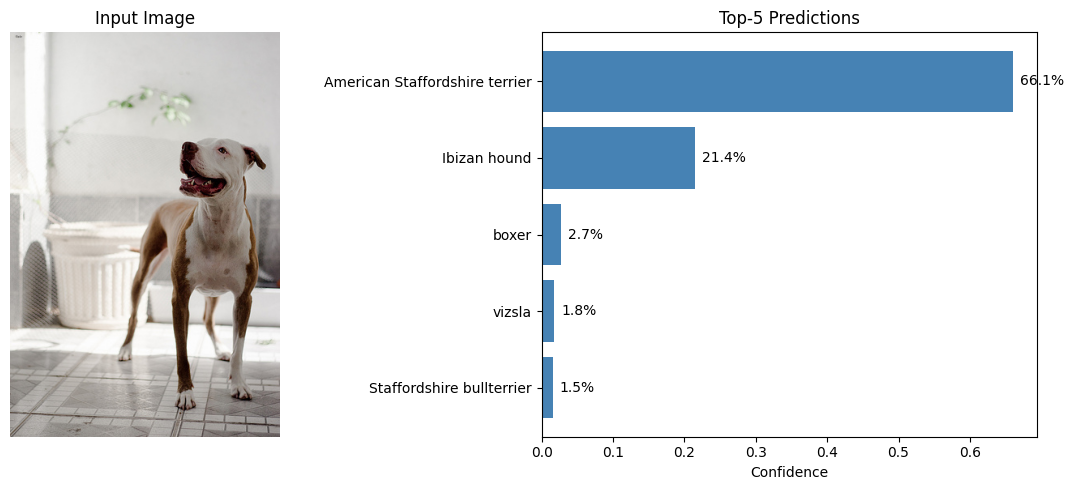


CLASSIFICATION RESULTS
1. American Staffordshire terrier - 66.08%
2. Ibizan hound - 21.42%
3. boxer - 2.70%
4. vizsla - 1.76%
5. Staffordshire bullterrier - 1.55%

MODEL INFORMATION
Model: facebook/dinov2-small-imagenet1k-1-layer
Number of classes: 1000
Model was fine-tuned on ImageNet-1k with 1000 classes


In [12]:
import torch
import torch.nn.functional as F
import matplotlib.pyplot as plt
from PIL import Image
from transformers import AutoImageProcessor, AutoModelForImageClassification
import requests
from io import BytesIO
import os
import glob

# Load model
MODEL_ID = "facebook/dinov2-small-imagenet1k-1-layer"
device = "cuda" if torch.cuda.is_available() else "cpu"

processor = AutoImageProcessor.from_pretrained(MODEL_ID)
model = AutoModelForImageClassification.from_pretrained(MODEL_ID).to(device)
model.eval()
print("Model loaded on", device)

def get_imagenet_labels():
    url = "https://raw.githubusercontent.com/pytorch/hub/master/imagenet_classes.txt"
    try:
        response = requests.get(url, timeout=10)
        labels = response.text.strip().split('\n')
        print("Loaded", len(labels), "ImageNet classes")
        return labels
    except:
        print("Using fallback labels")
        return ["dog", "cat", "car", "bird", "fish"]

imagenet_labels = get_imagenet_labels()

def classify_image(image_source, top_k=5):
    if isinstance(image_source, str):
        if image_source.startswith('http'):
            response = requests.get(image_source, timeout=10, headers={'User-Agent': 'Mozilla/5.0'})
            img = Image.open(BytesIO(response.content)).convert("RGB")
        else:
            img = Image.open(image_source).convert("RGB")
    elif isinstance(image_source, Image.Image):
        img = image_source
    else:
        raise ValueError("image_source must be URL string, file path, or PIL Image")

    inputs = processor(images=img, return_tensors="pt").to(device)

    with torch.no_grad():
        outputs = model(**inputs)
        logits = outputs.logits
        probabilities = F.softmax(logits, dim=1)

    top_probs, top_indices = torch.topk(probabilities, min(top_k, len(imagenet_labels)), dim=1)
    top_probs = top_probs.cpu().numpy()[0]
    top_indices = top_indices.cpu().numpy()[0]

    plt.figure(figsize=(12, 5))

    plt.subplot(1, 2, 1)
    plt.imshow(img)
    plt.axis('off')
    plt.title("Input Image")

    plt.subplot(1, 2, 2)
    labels = [imagenet_labels[idx].split(',')[0] if idx < len(imagenet_labels) else f"class_{idx}"
              for idx in top_indices]
    bars = plt.barh(range(len(labels)), top_probs, color='steelblue')
    plt.yticks(range(len(labels)), labels)
    plt.xlabel('Confidence')
    plt.title('Top-{} Predictions'.format(top_k))
    plt.gca().invert_yaxis()

    for i, bar in enumerate(bars):
        width = bar.get_width()
        plt.text(width + 0.01, bar.get_y() + bar.get_height()/2,
                '{:.1f}%'.format(width*100), va='center')

    plt.tight_layout()
    plt.show()

    print("\nCLASSIFICATION RESULTS")
    for i, (prob, idx) in enumerate(zip(top_probs, top_indices)):
        if idx < len(imagenet_labels):
            class_name = imagenet_labels[idx].split(',')[0]
        else:
            class_name = "class_{}".format(idx)
        print("{}. {} - {:.2f}%".format(i+1, class_name, prob*100))

    return top_indices[0], (imagenet_labels[top_indices[0]] if top_indices[0] < len(imagenet_labels) else "unknown")

print("\nTEST 1: Cat from Oxford Pets dataset")

cat_image_path = "data/images/Abyssinian_20.jpg"
try:
    classify_image(cat_image_path)
except:
    cat_images = glob.glob("data/images/*.jpg")
    cat_images = [f for f in cat_images if f.split('/')[-1][0].isupper()]
    if cat_images:
        classify_image(cat_images[0])

print("\nTEST 2: Dog from Oxford Pets dataset")

dog_image_path = "data/images/boxer_92.jpg"
try:
    classify_image(dog_image_path)
except:
    dog_images = glob.glob("data/images/*.jpg")
    dog_images = [f for f in dog_images if f.split('/')[-1][0].islower()]
    if dog_images:
        classify_image(dog_images[0])

print("\nTEST 3: Golden Retriever from web")

dog_url = "https://images.dog.ceo/breeds/retriever-golden/cache_3.jpg"
try:
    classify_image(dog_url)
except Exception as e:
    print("Could not download image:", e)

print("\nTEST 4: Sports car from web")

car_url = "https://upload.wikimedia.org/wikipedia/commons/thumb/1/10/Ferrari_488_GTB_in_Brussels.jpg/800px-Ferrari_488_GTB_in_Brussels.jpg"
try:
    classify_image(car_url)
except Exception as e:
    print("Could not download image:", e)

print("\nTesting multiple images")

cat_images = glob.glob("data/images/*.jpg")
cat_images = [f for f in cat_images if f.split('/')[-1][0].isupper()][:3]
dog_images = glob.glob("data/images/*.jpg")
dog_images = [f for f in dog_images if f.split('/')[-1][0].islower()][:3]

for img in cat_images:
    print("\nImage:", os.path.basename(img))
    classify_image(img)

for img in dog_images:
    print("\nImage:", os.path.basename(img))
    classify_image(img)

print("\nMODEL INFORMATION")
print("Model:", MODEL_ID)
print("Number of classes:", len(imagenet_labels))
print("Model was fine-tuned on ImageNet-1k with 1000 classes")